<b><h1><span style="color:thistle">Corelation Matrixes</h1>

<b>Task: Slice up time line by making corelation matrices using numpy class

1) Load data with montage, info etc.

    >Preload probably false

2) Butter your way to signal frequency of 1 - 45[Hz]

3) Downsample the signal for your <span style="color:thistle"> "Fuň Fuň FRrRrrRRRrRrrrrRrr" </span> laptop form 8000Hz to 250hz or something
    >Scippz signal decimate ?

    >target 250hz, q=int(8000/250), ftype='fir', axis=1

4) For every 10 seconds in all timeline create corr matric:

   >Matrix in numpy is kinda <span style="color:red"> deprecated </span> but I can still use it probably or make my own <span style="color:red"> OR </span> use ordinary numpy class

5) Count correlation for every channel 

   >numpy.corr? (correlate)

7) Save matrix or load them to memory

   >.npy -> np.load_data

8) Plot it!
   
<div style="text-align: right;"><i> Jesus take the wheel...Take it from my hand</div>
<div style="text-align: right;"><i> -Manka 2026</div>

<h2>Imports and Styling</h2>

In [1]:
import numpy as np
import mne
from elephant.signal_processing import butter
from scipy.signal import decimate
import matplotlib.pyplot as plt

import warnings as w
line = "\n❀----------------------------------------------------------❀\n"

<h2>Loading data, setting montage</h2>

In [2]:
path = "./../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica.fif"
with w.catch_warnings():
    w.simplefilter("ignore", RuntimeWarning)
    ica = mne.io.read_raw_fif(path, preload=False)
print(line)
ica.set_montage(mne.channels.make_standard_montage("standard_1005"))

Opening raw data file ./../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica.fif...
    Range : 0 ... 4287999 =      0.000 ...   536.000 secs
Ready.
Opening raw data file /home/manka/EEG/BoredEEG/Notebook/../bigData/C01/ica/C01_2024-11-16_10-44-51_RS_before_ica-1.fif...
    Range : 4288000 ... 4807672 =    536.000 ...   600.959 secs
Ready.

❀----------------------------------------------------------❀



<Raw | C01_2024-11-16_10-44-51_RS_before_ica.fif, 125 x 4807673 (601.0 s), ~152 KiB, data not loaded>

<h2>Band-pass filter (1–45 Hz)</h2>

Buttering or mne? thats the question... I would say lets do Butter first if I fail, then I try other solution

<span style="color:darkseagreen"><b>And this is Ladies & Gentlemans where this approach ENDS

In [3]:
"""
quart_ica = butter(
    ica.get_data(),
    highpass_frequency=0,
    lowpass_frequency=45
)
"""

'\nquart_ica = butter(\n    ica.get_data(),\n    highpass_frequency=0,\n    lowpass_frequency=45\n)\n'

<b><h1><span style="color:thistle">New approach</h1>

<b>Because applying filter on all data is RAM hungry, I need to take time snipplets first:

1) make cycle for 10s snipplets from data: <span style="color:lightsteelblue"><b>S</span></b>
   >apply filter on <span style="color:lightsteelblue"><b>S</span></b>
   >
   >downscale the <span style="color:lightsteelblue"><b>S</span></b>
   >
   >create matrix for <span style="color:lightsteelblue"><b>S</span></b>
   >
   >calculate matrix
   >
   >save matric
   >
   ><span style="color:darkseagreen"><b>repete</span></b>

<h3>Anti-allias Filter:</h3>

According to the Nyquist sampling theorem, the sampling rate should be at least twice the maximum frequency component of the signal of interest. In other words, the maximum frequency of the input signal should be less than or equal to half of the sampling rate.

Before sampling down 

<h3>Sampling down Decimate:</h3>

After anti-a filter. Mne does have it's own filter with resample, but [1] timing jitters can occur (NOT RELATED) and have some padding.

With MNE: 
```Python
ica.resample( sfreq=250, npad=auto)
```

<b>scipy.signal.decimate</b>

How the hell q, ftype and axis works ?

[1]<i>: You actually need to not be an idiot and build the imports for the inline documentation to work...

[[-2.98772007e-09 -6.46369074e-07 -9.92637524e-07 ...  1.59231877e-06
   1.23401890e-06  8.34406023e-07]
 [-1.89875138e-09 -9.37257141e-07 -1.37737595e-06 ...  3.45834110e-06
   4.04959610e-06  3.82266580e-06]
 [-2.88992386e-09 -1.58188755e-06 -2.29151692e-06 ... -7.33576769e-07
  -7.15847364e-07 -1.06371931e-06]
 ...
 [-3.70821290e-10 -1.73328885e-06 -3.15594048e-06 ...  2.27609050e-07
   8.00946680e-07  2.05502079e-06]
 [-5.59079283e-10 -3.20319282e-06 -5.79792004e-06 ...  1.25179974e-06
   1.60841569e-06  1.74146430e-06]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  4.17578121e-06
   4.07812513e-06  3.98046859e-06]]

❀----------------------------------------------------------❀

[[-8.63672298e-07 -8.37460766e-07 -8.11571914e-07 ...  8.67404317e-07
   8.67478839e-07  8.67538278e-07]
 [-1.68777382e-06 -1.56047668e-06 -1.43337285e-06 ...  6.17517191e-07
   6.17494032e-07  6.17476686e-07]
 [-2.67066975e-08  2.12411680e-08  6.92596793e-08 ...  7.93793108e-07
   7.93897464e-07  7.

TypeError: title() missing 1 required positional argument: 'label'

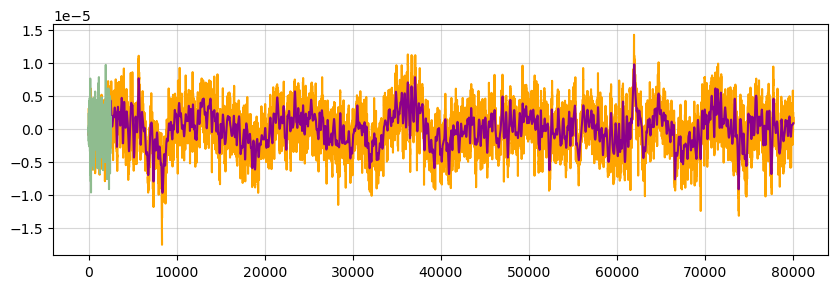

In [4]:
time_span=10
sampling_rate=ica.info['sfreq']
new_rate=250

jump=int(time_span*sampling_rate)

start=0
while(True): #Make cycle over 10s
    snipplet = ica.get_data(start=start, stop=jump) #create snipplets
    
    """
    Butter your way to 1–45 Hz 
    """
    quatro_s = butter( 
        snipplet,
        highpass_frequency=0,
        lowpass_frequency=45,
        filter_function='sosfiltfilt',
        sampling_frequency=sampling_rate
    )
    
    """
    Downsample (8000 → 250 Hz)
    """
    down_quatro_s = decimate(
        quatro_s,
        q = int(sampling_rate/new_rate),
        ftype='fir',
        axis=1
    )

    break

<h2>Plotting it's d</h2>

In [ ]:
plt.figure(figsize=(10,3))
plt.plot(snipplet[0], color='orange', label="Snipplet of 10s")
plt.plot(quatro_s[0], color='darkmagenta', label="Filter 1-45Hz")
plt.plot(down_quatro_s[0], color='darkseagreen', label="Downsample 8000 -> 250")
plt.grid(alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

print(snipplet.shape)
print(quatro_s.shape)
print(down_quatro_s.shape)